In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import math


In [3]:
np.random.seed(10)

In [6]:
x_sample=np.random.normal(0,1, 1000)

In [8]:
x_sample.shape

(1000,)

In [14]:
y_sample=np.random.normal(2*x_sample+1, 0.5, 1000) + np.random.normal(0, 0.5, 1000)

In [15]:
z_sample=np.random.normal(5*x_sample+1, 1, 1000) + np.random.normal(0, 0.5, 1000)

In [20]:
import pandas as pd

In [23]:
data_df=pd.DataFrame({'x': x_sample, 'y': y_sample, 'z': z_sample})

In [24]:
data_df


,x,y,z
0,1.097121,4.438965,5.415836
1,-0.538577,-1.689901,-0.574147
2,2.195597,6.535623,12.903198
3,-0.702644,1.174774,-0.325495
4,-0.060600,1.738612,0.582257
...,...,...,...
995,-1.237725,-1.674229,-5.053419
996,-0.141284,0.137412,-2.230571
997,-0.001291,-0.892043,1.804881
998,1.038500,3.539817,5.905471


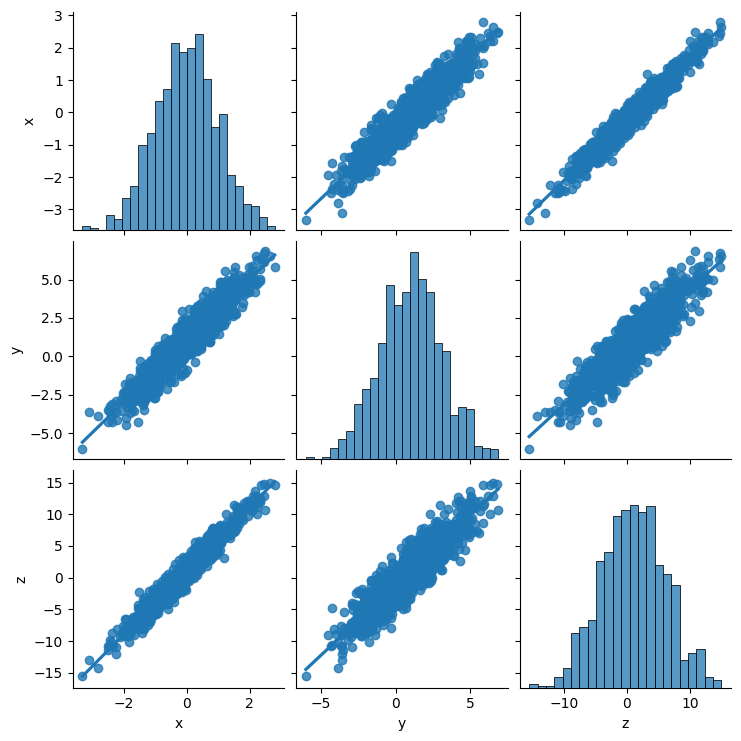

In [26]:
sns.pairplot(data_df, kind='reg')
plt.savefig('q2_pairwise_scatter.png')
plt.show()

All variables seem to be strongly positively correlated

In [28]:
corr_matrix=data_df.corr()

In [29]:
corr_matrix

,x,y,z
x,1.000000,0.939043,0.97632
y,0.939043,1.000000,0.91280
z,0.976320,0.912800,1.00000


<Axes: >

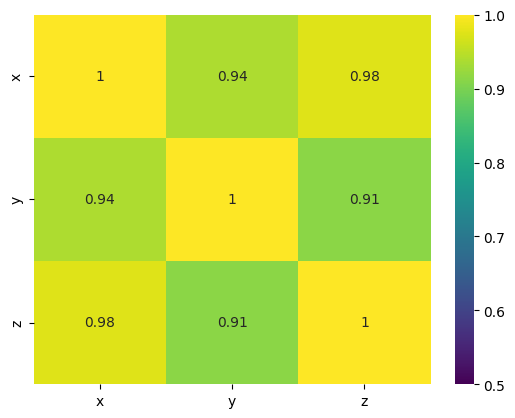

In [33]:
sns.heatmap(corr_matrix, cmap='viridis', vmin=0.5, vmax=+1, annot=True)

In [34]:
from sklearn.linear_model import LinearRegression

In [37]:
def part_corr(a): #here a is wrt which the part correlation is to be determined, unlike Q1 when the argument were the 2 target variables
    X=data_df[[a]] #keeping it as 1 column df
    y1=data_df.drop(columns=a).iloc[:, 0]
    y2=data_df.drop(columns=a).iloc[:, 1]
    model1=LinearRegression()
    model1.fit(X, y1)
    y1_pred=model1.predict(X)
    r1 = y1_pred-y1
    model2=LinearRegression()
    model2.fit(X, y2)
    y2_pred=model2.predict(X)
    r2=y2_pred-y2
    return np.corrcoef(r1, r2)[0, 1]
    
    
    

In [38]:
part_corr('x')

np.float64(-0.05387338411799928)

In [39]:
part_corr('y')

np.float64(0.8486661340856197)

In [42]:
part_corr('z')

np.float64(0.5416863604933606)

In [44]:
cov_matrix=data_df.cov()

In [45]:
inv_cov_matrix=np.linalg.inv(cov_matrix)

In [46]:
inv_cov_matrix

array([[31.3929596 , -4.23586227, -4.35589989],
       [-4.23586227,  1.9478504 ,  0.06887743],
       [-4.35589989,  0.06887743,  0.83916966]])

In [47]:
inv_cov_matrix_df=pd.DataFrame(inv_cov_matrix, index=cov_matrix.index, columns=cov_matrix.columns)

In [48]:
inv_cov_matrix_df

,x,y,z
x,31.392960,-4.235862,-4.355900
y,-4.235862,1.947850,0.068877
z,-4.355900,0.068877,0.839170


In [49]:
#rescaling
K=np.zeros_like(inv_cov_matrix)
for i in range(inv_cov_matrix.shape[0]):
    K[i, i]=1
    for j in range(i+1, inv_cov_matrix.shape[0]):
        K[i, j]= -(inv_cov_matrix[i, j])/np.sqrt(inv_cov_matrix[i, i]* inv_cov_matrix[j, j])
        K[j, i]= K[i, j]
    

In [51]:
K_df=pd.DataFrame(K, index=inv_cov_matrix_df.index, columns=inv_cov_matrix_df.columns)

In [52]:
K_df

,x,y,z
x,1.000000,0.541686,0.848666
y,0.541686,1.000000,-0.053873
z,0.848666,-0.053873,1.000000


We see that the result matches the partial correlations computed manually using linear regression 

<Axes: >

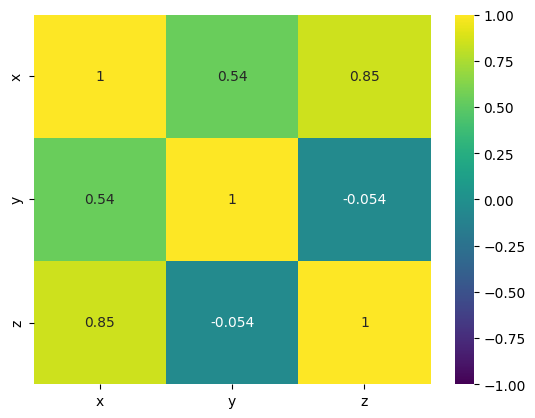

In [53]:
sns.heatmap(K_df, cmap='viridis', vmin=-1, vmax=+1, annot=True)

From the heatmap it is clear that the variables y and z are conditionally independent given x

This follows from the extremely small partial correlation between them